# Computer Vision - P2

==============================================================================================
## Practicum 2: Filtering and edge detection

==============================================================================================

The main topics are:
1. Image smoothing and convolution (exercises 2.1, 2.2, 2.3 and 2.4)
2. Edge detection (exercises 2.5, 2.6 and 2.7)

In order to complete this practicum, the following concepts need to be understood: linear filters, histograms, convolutions, and edges.

The following chapters of the book "Computer Vision: Algorithms and Applications" by Richard Szeliski provide additional information:
* Chapter 3. Image processing: Point operators & linear filtering.
* Chapter 4. Feature detection and matching: Edges.

### 2.1 RGB histogram visualization

a) Read the image `./images_notebook/oryx.jpg` and visualize the RGB image as well as each of its channels separately (R, G, and B). Print the image shape and data type.

<img src="images_notebook/oryx.jpg">

**Note:** Before applying the histogram, you should pass the image into float.

Image shape: (800, 1200, 3)
Image dtype: uint8


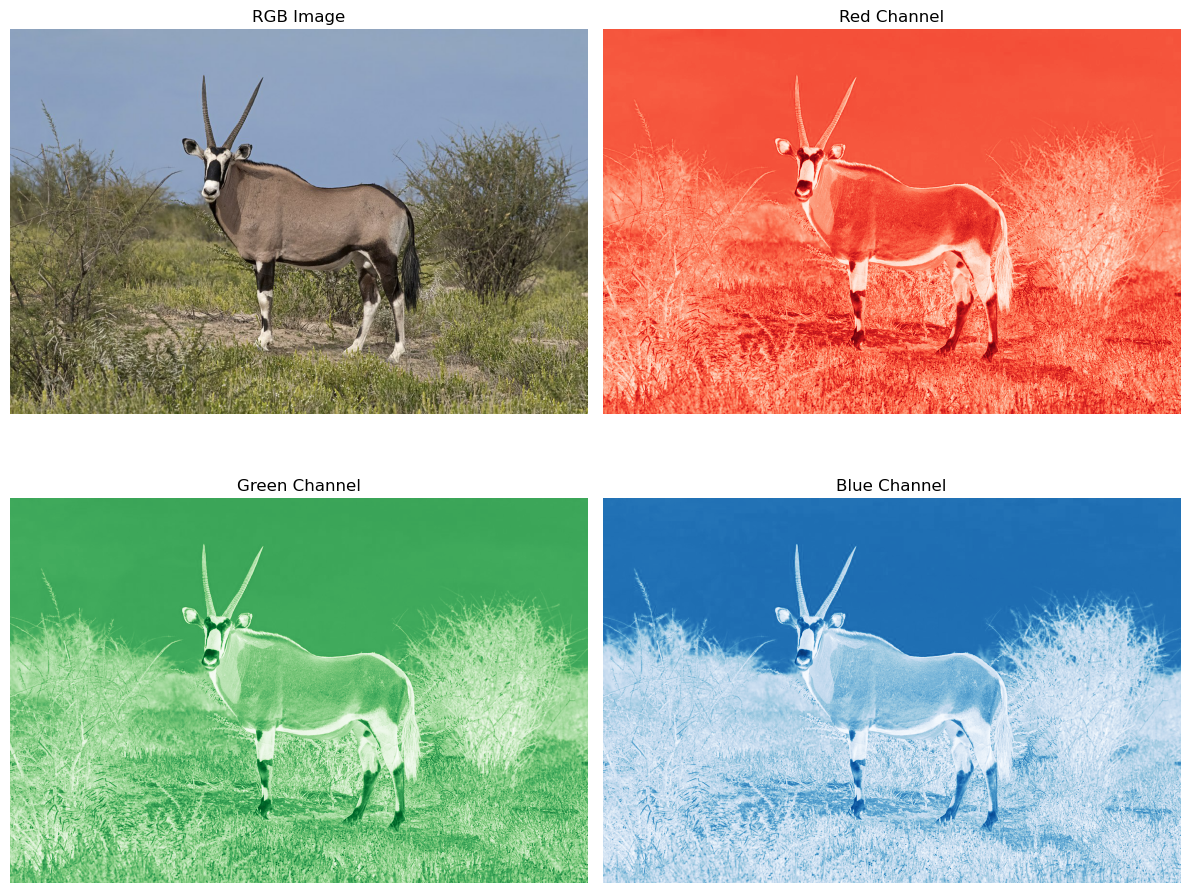


Float image dtype: float64
Float image range: [0.0, 1.0]


In [1]:
from skimage import io
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
import numpy as np

# Read the image
oryx = io.imread('./images_notebook/oryx.jpg')

# Print image properties
print(f"Image shape: {oryx.shape}")
print(f"Image dtype: {oryx.dtype}")

# Visualize RGB image and separate channels
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(oryx)
axes[0, 0].set_title('RGB Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(oryx[:,:,0], cmap='Reds')
axes[0, 1].set_title('Red Channel')
axes[0, 1].axis('off')

axes[1, 0].imshow(oryx[:,:,1], cmap='Greens')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(oryx[:,:,2], cmap='Blues')
axes[1, 1].set_title('Blue Channel')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Convert to float for histogram processing
oryx_float = oryx.astype(float) / 255.0
print(f"\nFloat image dtype: {oryx_float.dtype}")
print(f"Float image range: [{oryx_float.min()}, {oryx_float.max()}]")

b) Make a function `im_hist(im,  nbins=8)` to visualize the histogram of the RGB, and grayscale images. What is the histogram representing for an image? 

The plotted histogram must accomplish these requirements (see image bellow as an example of histogram extraction):

- Obtain the histogram with 16, 32, 64 and 256 bins. What are the bins representing?

- Visualize the histogram of each channel and the gray level image separately and compare them. Comment their differences (between different channels and different number of bins).

**Note:** What type should be the image in order to compute the histogram? Check using different bins for the histogram. 

**Hint** : the `exposure` module within the `skimage` library makes the histogram extraction easy!

**Help:** [matplotlib image tutorial](https://matplotlib.org/users/image_tutorial.html)

<img src='images_notebook/histograms.png'>

Histogram represents the distribution of pixel intensities in the image.
Bins represent intervals of intensity values that group similar pixels together.


--- Testing with 16 bins ---


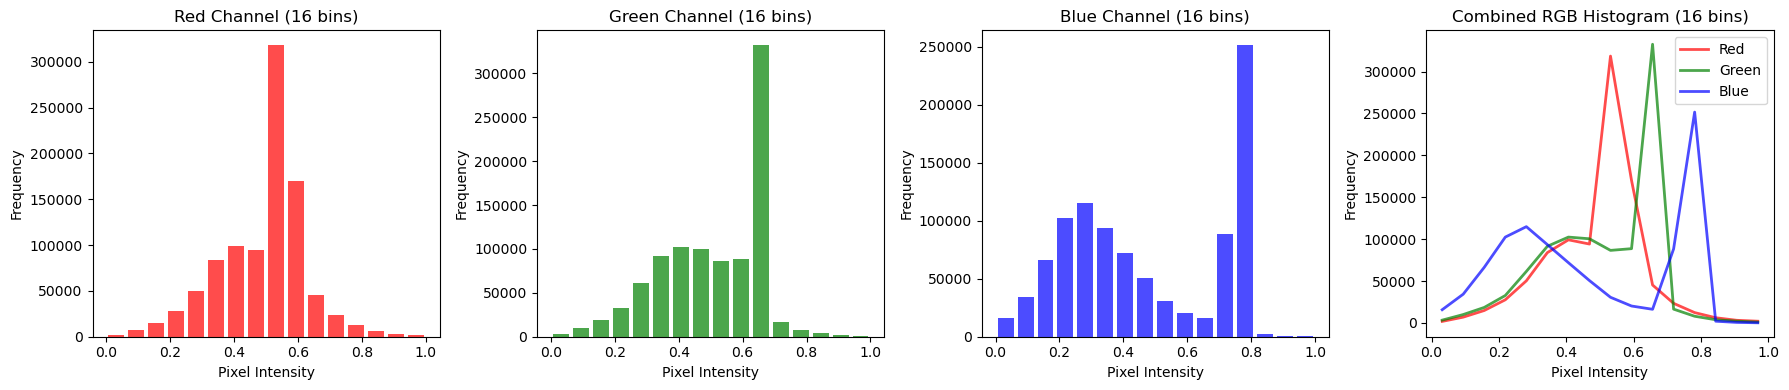


--- Testing with 32 bins ---


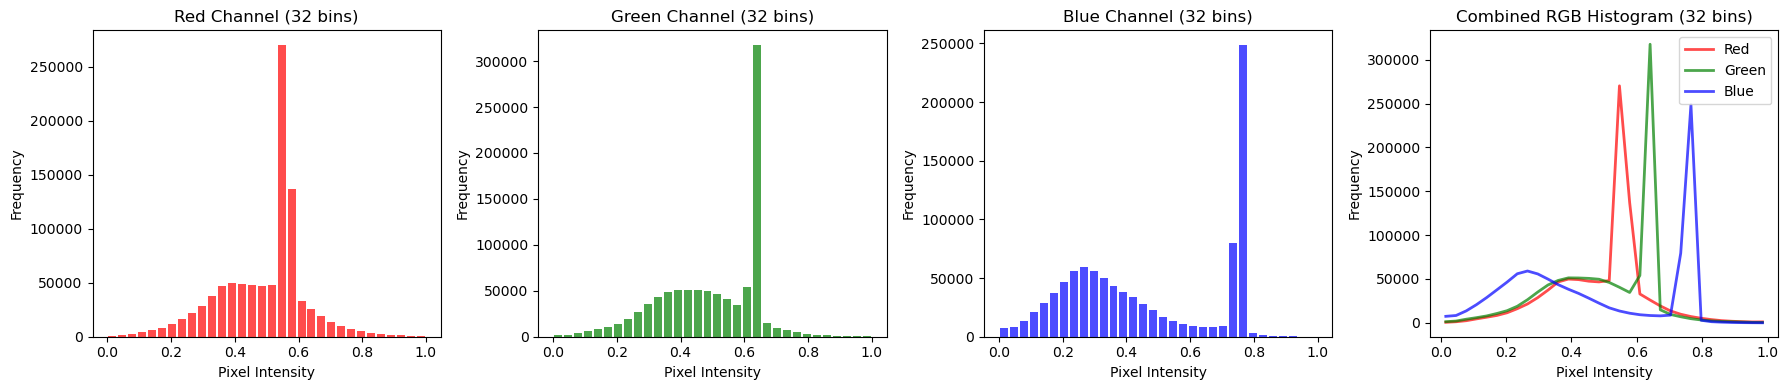


--- Testing with 64 bins ---


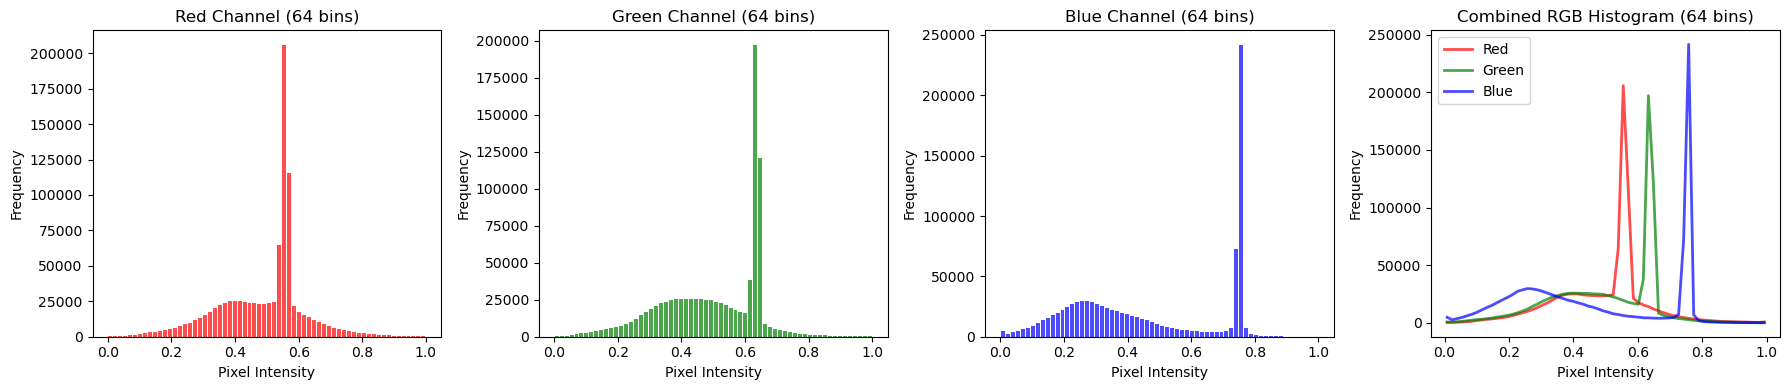


--- Testing with 256 bins ---


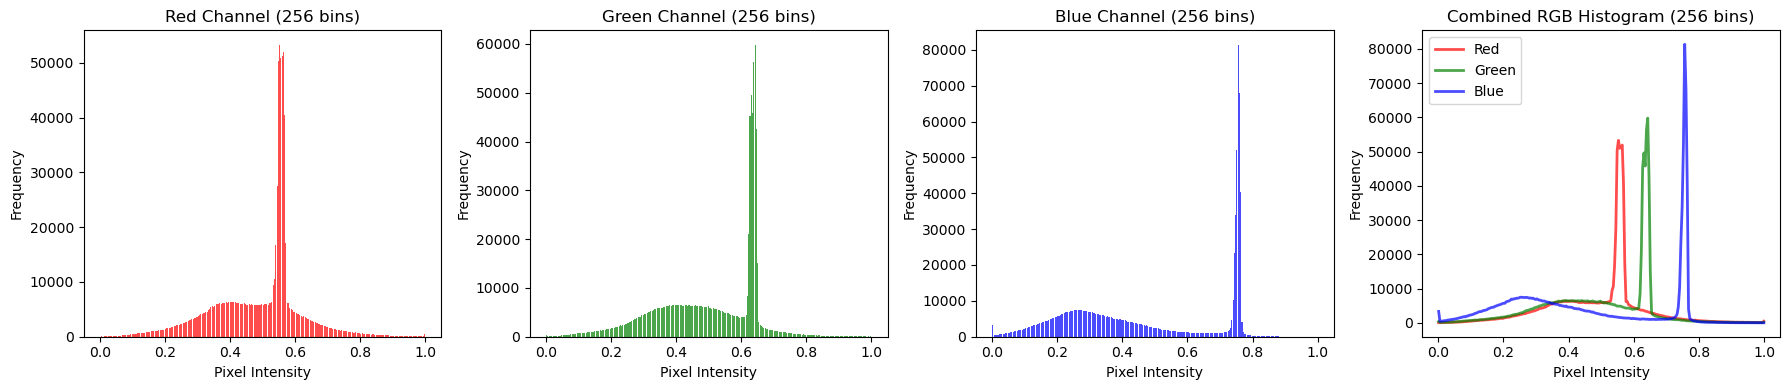


--- Grayscale Image Histograms ---


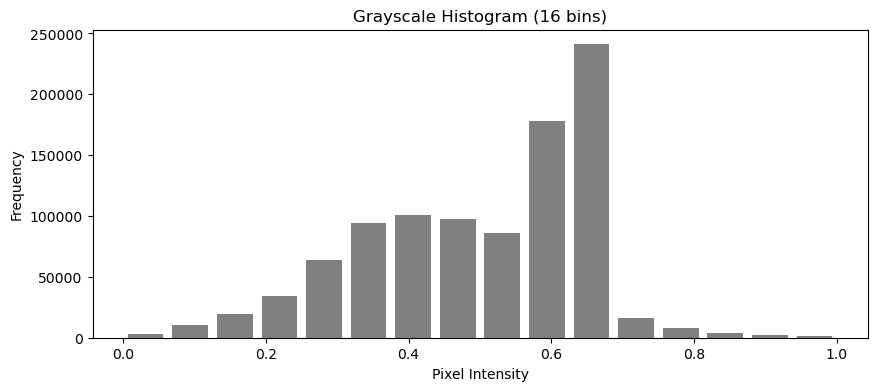

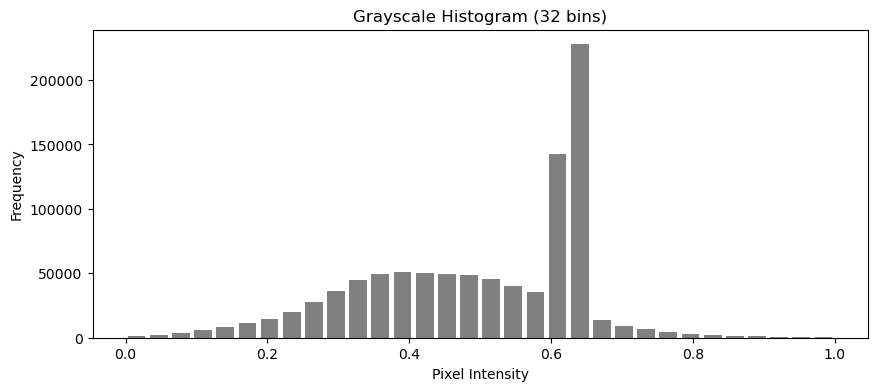

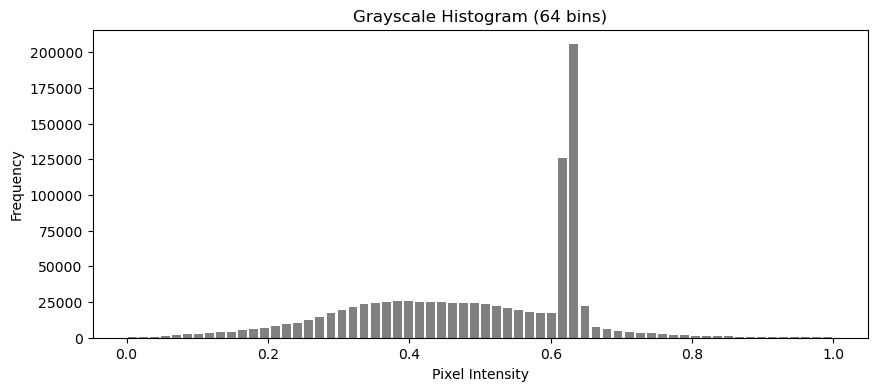

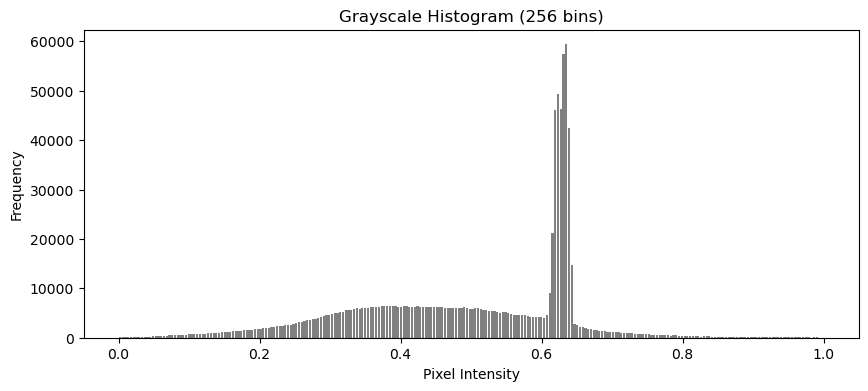


Observations:
- More bins provide finer detail about intensity distribution
- Fewer bins show more general patterns
- Different channels show different distributions based on image colors
- Grayscale combines all channel information into a single intensity value


In [3]:
from skimage.exposure import histogram

def im_hist(im, nbins=8):
    """
    Visualize histogram of RGB or grayscale image.
    
    Parameters:
    -----------
    im : ndarray
        Input image (RGB or grayscale)
    nbins : int
        Number of bins for the histogram
    """
    # Convert to float if not already
    if im.dtype != float:
        im = im.astype(float) / 255.0
    
    # Check if grayscale or RGB
    if len(im.shape) == 2:
        # Grayscale image
        hist, bins = histogram(im, nbins=nbins)
        
        plt.figure(figsize=(10, 4))
        plt.bar(bins, hist, width=(bins[1]-bins[0])*0.8, color='gray')
        plt.title(f'Grayscale Histogram ({nbins} bins)')
        plt.xlabel('Pixel Intensity')
        plt.ylabel('Frequency')
        plt.show()
    else:
        # RGB image
        fig, axes = plt.subplots(1, 4, figsize=(18, 4))
        colors = ['red', 'green', 'blue']
        
        # Histograms for each channel
        for i, (color, ax) in enumerate(zip(colors, axes[:3])):
            hist, bins = histogram(im[:,:,i], nbins=nbins)
            ax.bar(bins, hist, width=(bins[1]-bins[0])*0.8, color=color, alpha=0.7)
            ax.set_title(f'{color.capitalize()} Channel ({nbins} bins)')
            ax.set_xlabel('Pixel Intensity')
            ax.set_ylabel('Frequency')
        
        # Combined histogram
        for i, color in enumerate(colors):
            hist, bins = histogram(im[:,:,i], nbins=nbins)
            axes[3].plot(bins, hist, color=color, alpha=0.7, linewidth=2, label=color.capitalize())
        axes[3].set_title(f'Combined RGB Histogram ({nbins} bins)')
        axes[3].set_xlabel('Pixel Intensity')
        axes[3].set_ylabel('Frequency')
        axes[3].legend()
        
        plt.tight_layout()
        plt.show()

# Test the function with different number of bins
print("Histogram represents the distribution of pixel intensities in the image.")
print("Bins represent intervals of intensity values that group similar pixels together.\n")

# Convert oryx to grayscale
oryx_gray = rgb2gray(oryx)

# Test with different bins for RGB image
for bins in [16, 32, 64, 256]:
    print(f"\n--- Testing with {bins} bins ---")
    im_hist(oryx_float, nbins=bins)

# Test with grayscale image
print("\n--- Grayscale Image Histograms ---")
for bins in [16, 32, 64, 256]:
    im_hist(oryx_gray, nbins=bins)

print("\nObservations:")
print("- More bins provide finer detail about intensity distribution")
print("- Fewer bins show more general patterns")
print("- Different channels show different distributions based on image colors")
print("- Grayscale combines all channel information into a single intensity value")

### 2.2 Grayscale and RGB images filtering (convolutions)

a) Read the image `./images_notebook/oryx.jpg`. Reshape the image to $256x256$ pixels and convert to gray scale (i.e. `oryx_gray`). We are going to apply:

1. Convolve `oryx_gray` with a horizontal mask `mask_h1d=[[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]]` using the function `ndimage.convolve()` of the package `scipy`.
2. Convolve `oryx_gray` with a transposed version of the mask in (2).
3. Convolve `oryx_gray` with a uniform `two-dimensional` mask of dimensions 15x15 with all values set to 1.

Check the maximum and minimum values, as well as the data type of each imagea.

- Is the type of the mask important for the convolution? What effect does each of the masks produce on the original image? Compare the results.


**Note:** The command `convolve` performs a multidimensional convolution! A vector should be represented as: [[1,...1]].

**Note:** Remember that before applying the `convolve` function the mask must be normalized (i.e. all values in the mask must sum 1).


In [5]:
from scipy import ndimage
from skimage.transform import resize

# Read and prepare image
oryx = io.imread('./images_notebook/oryx.jpg')
oryx_resized = resize(oryx, (256, 256), anti_aliasing=True)
oryx_gray = rgb2gray(oryx_resized)

print(f"Original oryx_gray - dtype: {oryx_gray.dtype}, min: {oryx_gray.min():.4f}, max: {oryx_gray.max():.4f}")

# 1. Horizontal mask
mask_h1d = np.array([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]], dtype=float)
mask_h1d = mask_h1d / np.sum(mask_h1d)  # Normalize

oryx_conv_h = ndimage.convolve(oryx_gray, mask_h1d, mode='constant', cval=0.0)
print(f"\nHorizontal convolution - dtype: {oryx_conv_h.dtype}, min: {oryx_conv_h.min():.4f}, max: {oryx_conv_h.max():.4f}")

# 2. Vertical mask (transposed)
mask_v1d = mask_h1d.T

oryx_conv_v = ndimage.convolve(oryx_gray, mask_v1d, mode='constant', cval=0.0)
print(f"Vertical convolution - dtype: {oryx_conv_v.dtype}, min: {oryx_conv_v.min():.4f}, max: {oryx_conv_v.max():.4f}")

# 3. 2D uniform mask 15x15
mask_2d = np.ones((15, 15), dtype=float)
mask_2d = mask_2d / np.sum(mask_2d)  # Normalize

oryx_conv_2d = ndimage.convolve(oryx_gray, mask_2d, mode='constant', cval=0.0)
print(f"2D convolution - dtype: {oryx_conv_2d.dtype}, min: {oryx_conv_2d.min():.4f}, max: {oryx_conv_2d.max():.4f}")

print("\nAnalysis:")
print("- Mask type is important: float masks preserve precision")
print("- Horizontal mask: blurs horizontally, preserves vertical edges")
print("- Vertical mask: blurs vertically, preserves horizontal edges")
print("- 2D mask: blurs in all directions (uniform smoothing)")

Original oryx_gray - dtype: float64, min: 0.0239, max: 0.9856

Horizontal convolution - dtype: float64, min: 0.0793, max: 0.7391
Vertical convolution - dtype: float64, min: 0.0976, max: 0.8314
2D convolution - dtype: float64, min: 0.1368, max: 0.6407

Analysis:
- Mask type is important: float masks preserve precision
- Horizontal mask: blurs horizontally, preserves vertical edges
- Vertical mask: blurs vertically, preserves horizontal edges
- 2D mask: blurs in all directions (uniform smoothing)


b) Visualize the four images, `oryx_gray` and the output of each step (1 to 3) in a single figure, with the corresponding titles.


Note: Remember that `matplotlib.pyplot` automatically rescales the values of the image before displaying them. Visualize with and without pixel values range rescaling.


In [ ]:
# Visualize all four images
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Without rescaling (vmin and vmax set)
axes[0, 0].imshow(oryx_gray, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('Original oryx_gray')
axes[0, 0].axis('off')

axes[0, 1].imshow(oryx_conv_h, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Horizontal convolution')
axes[0, 1].axis('off')

axes[1, 0].imshow(oryx_conv_v, cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title('Vertical convolution')
axes[1, 0].axis('off')

axes[1, 1].imshow(oryx_conv_2d, cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title('2D convolution (15x15)')
axes[1, 1].axis('off')

plt.suptitle('With pixel value range [0, 1]', fontsize=14)
plt.tight_layout()
plt.show()

# With automatic rescaling
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(oryx_gray, cmap='gray')
axes[0, 0].set_title('Original oryx_gray')
axes[0, 0].axis('off')

axes[0, 1].imshow(oryx_conv_h, cmap='gray')
axes[0, 1].set_title('Horizontal convolution')
axes[0, 1].axis('off')

axes[1, 0].imshow(oryx_conv_v, cmap='gray')
axes[1, 0].set_title('Vertical convolution')
axes[1, 0].axis('off')

axes[1, 1].imshow(oryx_conv_2d, cmap='gray')
axes[1, 1].set_title('2D convolution (15x15)')
axes[1, 1].axis('off')

plt.suptitle('With automatic rescaling', fontsize=14)
plt.tight_layout()
plt.show()

c) Can we convolve a color (RGB) image? 

Implement a function `conv_coor(image, mask)` that applies a 3-channel filter.  Reshape the original `oryx.jpg` image to $256x256$ pixels and try your funcion, using a 7x7 uniform mask.


In [ ]:
def conv_color(image, mask):
    """
    Apply convolution to a color (RGB) image by convolving each channel separately.
    
    Parameters:
    -----------
    image : ndarray
        Input RGB image (H x W x 3)
    mask : ndarray
        Convolution kernel/mask (normalized)
    
    Returns:
    --------
    result : ndarray
        Convolved RGB image
    """
    # Make sure mask is normalized
    mask_norm = mask / np.sum(mask)
    
    # Initialize output image
    result = np.zeros_like(image, dtype=float)
    
    # Convolve each channel separately
    for i in range(3):
        result[:, :, i] = ndimage.convolve(image[:, :, i], mask_norm, mode='constant', cval=0.0)
    
    return result

# Read and resize original RGB image
oryx_rgb = io.imread('./images_notebook/oryx.jpg')
oryx_rgb_resized = resize(oryx_rgb, (256, 256), anti_aliasing=True)

# Create 7x7 uniform mask
mask_7x7 = np.ones((7, 7))

# Apply convolution to color image
oryx_rgb_conv = conv_color(oryx_rgb_resized, mask_7x7)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(oryx_rgb_resized)
axes[0].set_title('Original RGB Image (256x256)')
axes[0].axis('off')

axes[1].imshow(oryx_rgb_conv)
axes[1].set_title('Convolved RGB Image (7x7 uniform mask)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("Yes, we can convolve a color (RGB) image!")
print("We apply the mask to each color channel independently.")

FileNotFoundError: No such file: 'c:\Users\josea\Desktop\Github\UB\Tercero\Primer Semestre\VA\Pt_2\p2-20251025\images_notebook\oryx.png'

### 2.3 Effect of image scale on convolutions

a) Resize an image and observe the variations in the histograms.

1. Reduce `oryx_gray` 20 times, and check the histogram (i.e. nbins = 32)
2. Augment `oryx_gray` 20 times, and check its histogram (i.e. nbins = 32)

Is there any difference? Please, comment what happens and why.


Reduced image shape: (13, 13)
Augmented image shape: (5120, 5120)


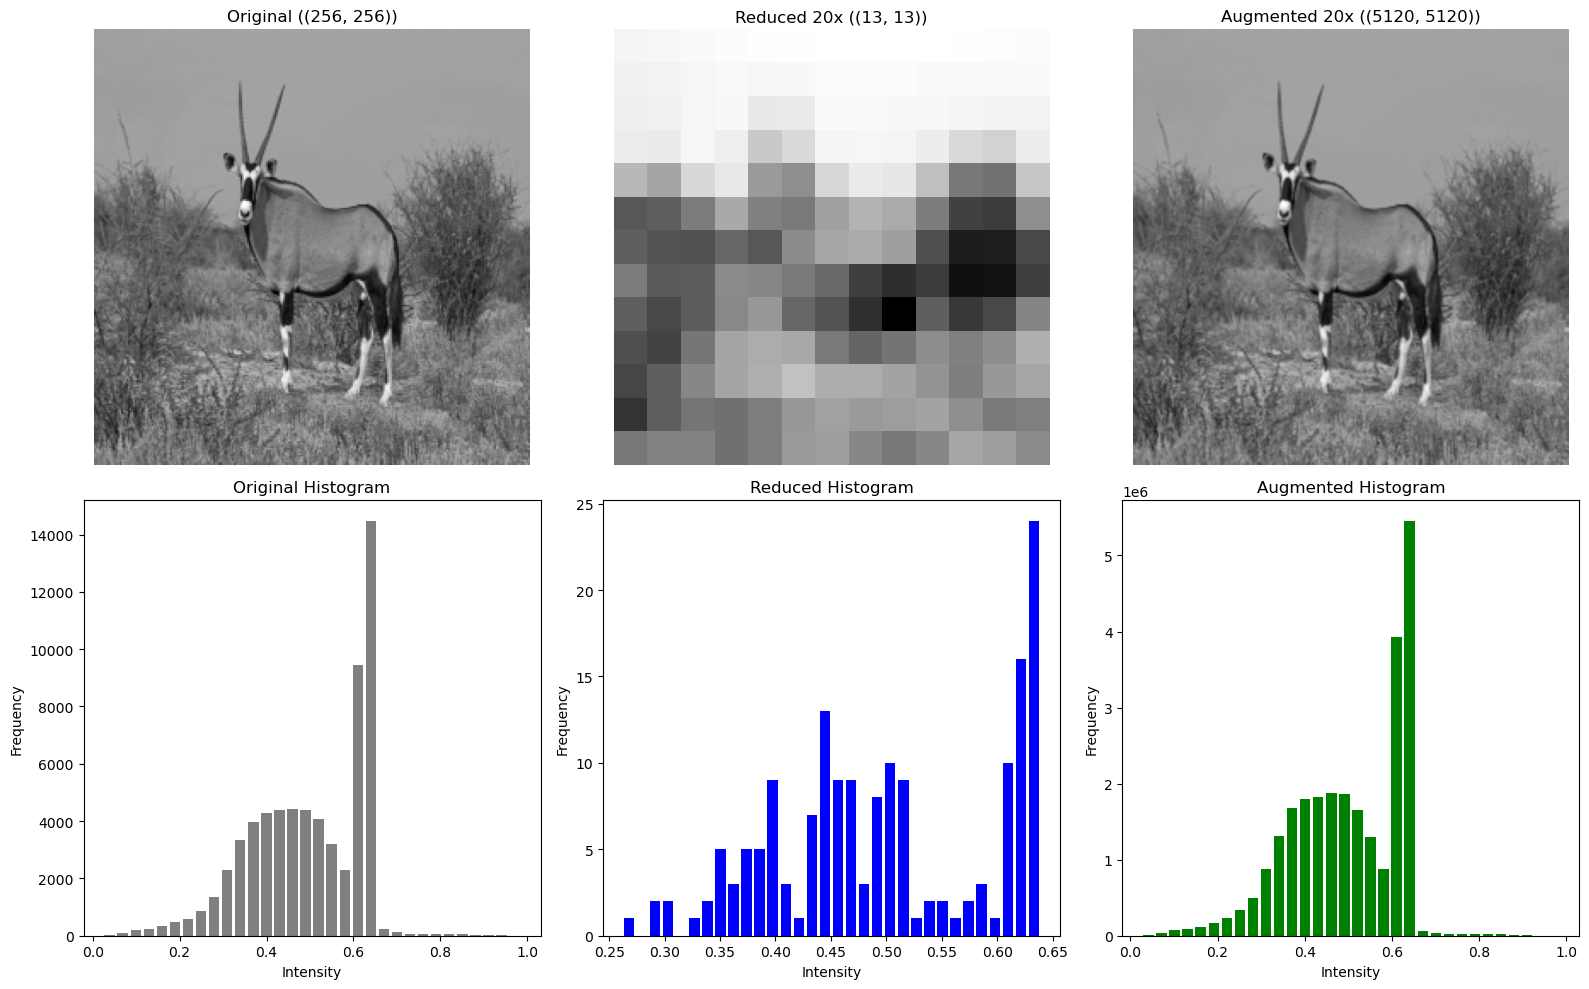


Analysis:
- Reduced image: anti-aliasing smooths the image, histogram shows less variety
- Augmented image: interpolation creates new pixel values, histogram shows similar distribution
- The histogram shape is preserved but the frequency counts change with image size


In [17]:
from skimage.transform import rescale

# 1. Reduce oryx_gray 20 times
oryx_reduced = rescale(oryx_gray, 1/20, anti_aliasing=True)
print(f"Reduced image shape: {oryx_reduced.shape}")

# 2. Augment oryx_gray 20 times
oryx_augmented = rescale(oryx_gray, 20, anti_aliasing=False)
print(f"Augmented image shape: {oryx_augmented.shape}")

# Calculate histograms
hist_original, bins_original = histogram(oryx_gray, nbins=32)
hist_reduced, bins_reduced = histogram(oryx_reduced, nbins=32)
hist_augmented, bins_augmented = histogram(oryx_augmented, nbins=32)

# Visualize images and histograms
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Images
axes[0, 0].imshow(oryx_gray, cmap='gray')
axes[0, 0].set_title(f'Original ({oryx_gray.shape})')
axes[0, 0].axis('off')

axes[0, 1].imshow(oryx_reduced, cmap='gray')
axes[0, 1].set_title(f'Reduced 20x ({oryx_reduced.shape})')
axes[0, 1].axis('off')

axes[0, 2].imshow(oryx_augmented, cmap='gray')
axes[0, 2].set_title(f'Augmented 20x ({oryx_augmented.shape})')
axes[0, 2].axis('off')

# Histograms
axes[1, 0].bar(bins_original, hist_original, width=(bins_original[1]-bins_original[0])*0.8, color='gray')
axes[1, 0].set_title('Original Histogram')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].bar(bins_reduced, hist_reduced, width=(bins_reduced[1]-bins_reduced[0])*0.8, color='blue')
axes[1, 1].set_title('Reduced Histogram')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Frequency')

axes[1, 2].bar(bins_augmented, hist_augmented, width=(bins_augmented[1]-bins_augmented[0])*0.8, color='green')
axes[1, 2].set_title('Augmented Histogram')
axes[1, 2].set_xlabel('Intensity')
axes[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nAnalysis:")
print("- Reduced image: anti-aliasing smooths the image, histogram shows less variety")
print("- Augmented image: interpolation creates new pixel values, histogram shows similar distribution")
print("- The histogram shape is preserved but the frequency counts change with image size")

b) Apply a convolution (7x7 uniform mask) on the resized images, calculate the histograms and compare the results.

1. Convolve the original `oryx_gray`image and calculate its histogram.
2. Convolve the reduced `oryx_gray` image 20 times and calculate its histogram.
3. Convolve the augmented `oryx_gray` image 20 times and calculate its histogram.

Comment what happens and why.

In [ ]:
# Create 7x7 uniform mask
mask_7x7 = np.ones((7, 7))
mask_7x7 = mask_7x7 / np.sum(mask_7x7)

# 1. Convolve original image
oryx_conv_original = ndimage.convolve(oryx_gray, mask_7x7, mode='constant', cval=0.0)
hist_conv_original, bins_conv_original = histogram(oryx_conv_original, nbins=32)

# 2. Convolve reduced image
oryx_conv_reduced = ndimage.convolve(oryx_reduced, mask_7x7, mode='constant', cval=0.0)
hist_conv_reduced, bins_conv_reduced = histogram(oryx_conv_reduced, nbins=32)

# 3. Convolve augmented image
oryx_conv_augmented = ndimage.convolve(oryx_augmented, mask_7x7, mode='constant', cval=0.0)
hist_conv_augmented, bins_conv_augmented = histogram(oryx_conv_augmented, nbins=32)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Convolved images
axes[0, 0].imshow(oryx_conv_original, cmap='gray')
axes[0, 0].set_title('Original Convolved')
axes[0, 0].axis('off')

axes[0, 1].imshow(oryx_conv_reduced, cmap='gray')
axes[0, 1].set_title('Reduced Convolved')
axes[0, 1].axis('off')

axes[0, 2].imshow(oryx_conv_augmented, cmap='gray')
axes[0, 2].set_title('Augmented Convolved')
axes[0, 2].axis('off')

# Histograms
axes[1, 0].bar(bins_conv_original, hist_conv_original, width=(bins_conv_original[1]-bins_conv_original[0])*0.8, color='gray')
axes[1, 0].set_title('Original Conv. Histogram')

axes[1, 1].bar(bins_conv_reduced, hist_conv_reduced, width=(bins_conv_reduced[1]-bins_conv_reduced[0])*0.8, color='blue')
axes[1, 1].set_title('Reduced Conv. Histogram')

axes[1, 2].bar(bins_conv_augmented, hist_conv_augmented, width=(bins_conv_augmented[1]-bins_conv_augmented[0])*0.8, color='green')
axes[1, 2].set_title('Augmented Conv. Histogram')

plt.tight_layout()
plt.show()

print("\nAnalysis:")
print("- Fixed-size kernel (7x7) has different relative effects at different scales")
print("- On reduced image: kernel covers larger relative area, more smoothing")
print("- On augmented image: kernel covers smaller relative area, less visible smoothing")
print("- Histograms reflect this: reduced image histogram is narrower (more blurred)")

### 2.4 Image processing with weighting and non-linear filters

a) Generate the following kernels and apply them to the `oryx_gray` image:

1. Gaussian kernel with sigma = 1
2. Gaussian kernel with 3 different sigma values. Which is the most adequate value for keeping the main objects and structures of the image?
3. Median filter with different mask shapes: disk, rectangle, and diamond. What is the effect of using different kinds of filters on the original image?

Comment the effect of using different kinds of filters on the original image.

**Hint:** Search for the [skimage.filters function](https://scikit-image.org/docs/stable/api/skimage.filters.html) for creating the different filters.

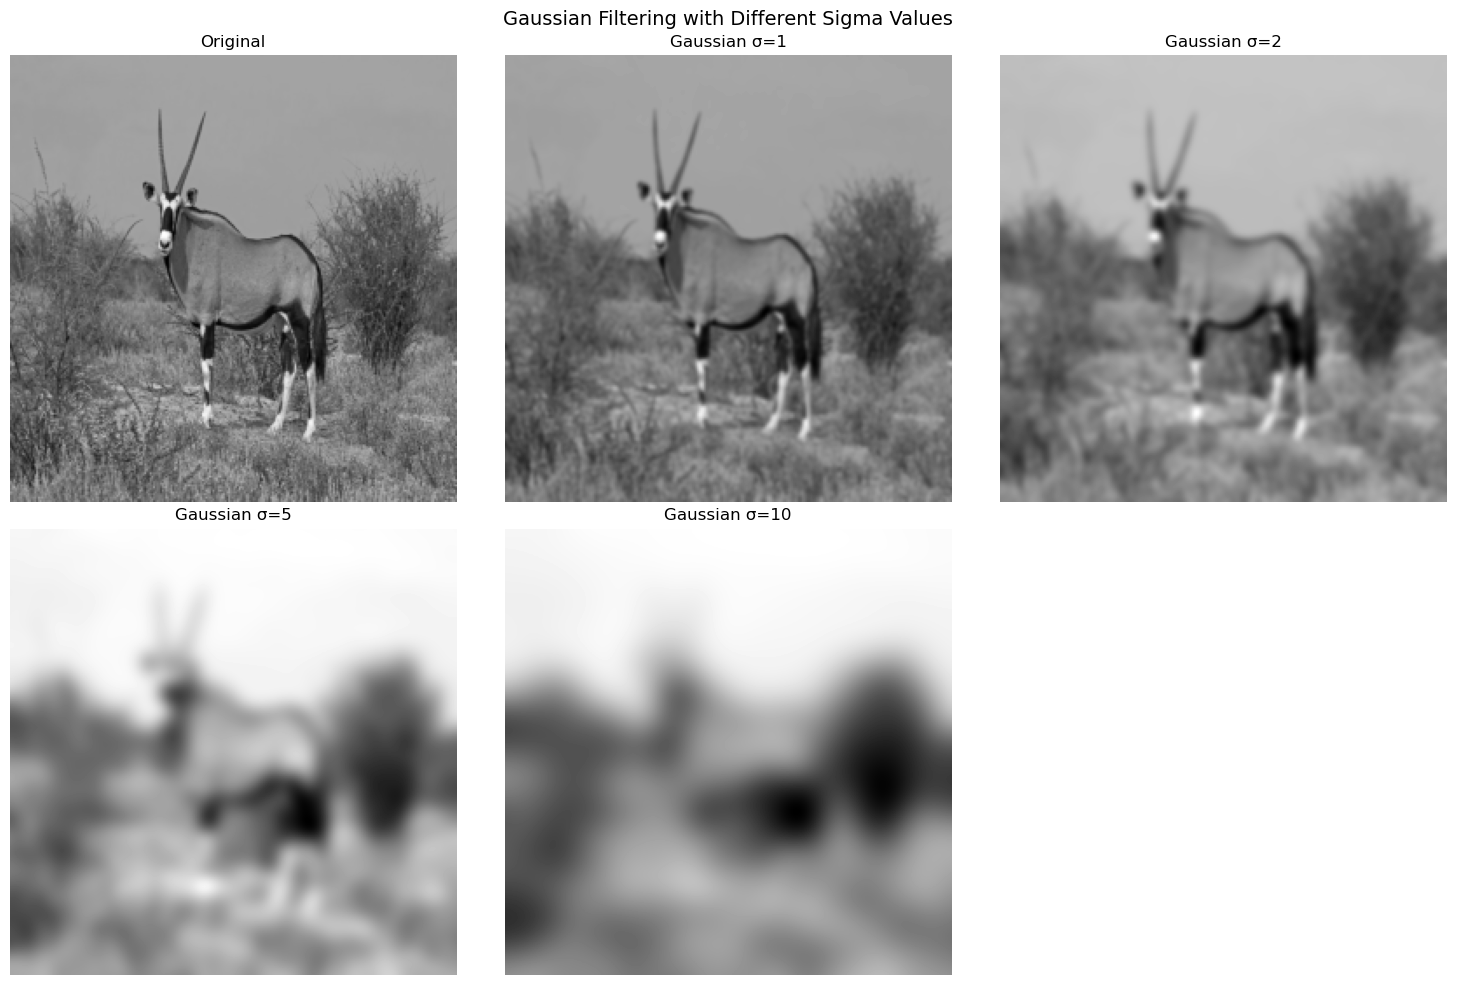

Optimal sigma for preserving main objects: σ=2 to σ=5
- σ=1: minimal smoothing, preserves details
- σ=2-5: good balance between smoothing and structure preservation
- σ=10: too much smoothing, loses important details


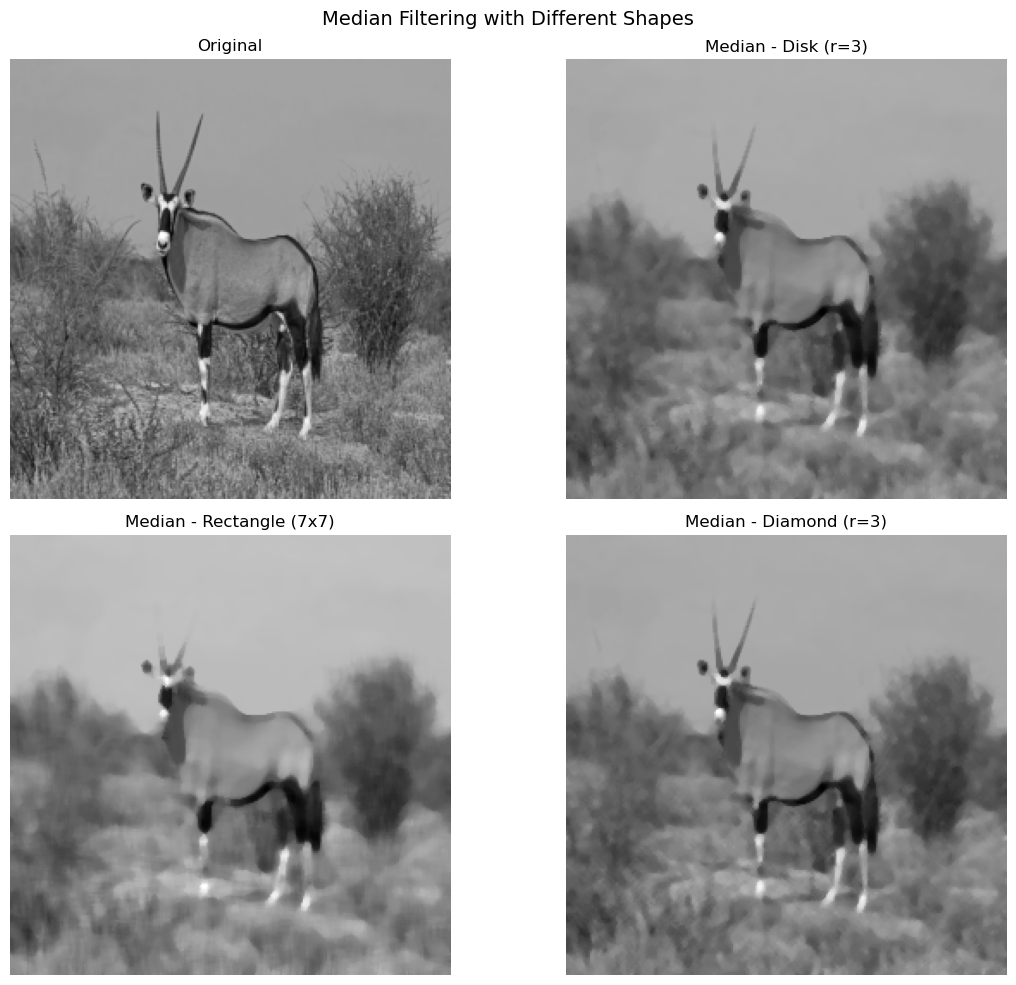

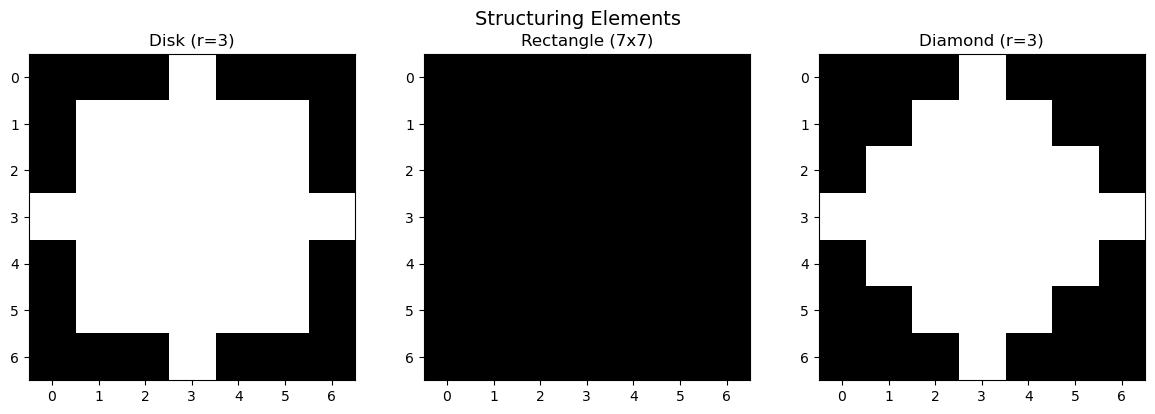


Median Filter Effects:
- Disk: circular neighborhood, good for general smoothing
- Rectangle: square neighborhood, preserves straight edges better
- Diamond: diamond-shaped, compromise between disk and rectangle
- All median filters preserve edges better than Gaussian while removing noise


In [9]:
from skimage.filters import gaussian, median
from skimage.morphology import disk, rectangle, diamond

# 1. Gaussian kernel with sigma = 1
oryx_gauss_1 = gaussian(oryx_gray, sigma=1)

# 2. Gaussian with different sigma values
oryx_gauss_2 = gaussian(oryx_gray, sigma=2)
oryx_gauss_5 = gaussian(oryx_gray, sigma=5)
oryx_gauss_10 = gaussian(oryx_gray, sigma=10)

# Visualize Gaussian results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(oryx_gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(oryx_gauss_1, cmap='gray')
axes[0, 1].set_title('Gaussian σ=1')
axes[0, 1].axis('off')

axes[0, 2].imshow(oryx_gauss_2, cmap='gray')
axes[0, 2].set_title('Gaussian σ=2')
axes[0, 2].axis('off')

axes[1, 0].imshow(oryx_gauss_5, cmap='gray')
axes[1, 0].set_title('Gaussian σ=5')
axes[1, 0].axis('off')

axes[1, 1].imshow(oryx_gauss_10, cmap='gray')
axes[1, 1].set_title('Gaussian σ=10')
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.suptitle('Gaussian Filtering with Different Sigma Values', fontsize=14)
plt.tight_layout()
plt.show()

print("Optimal sigma for preserving main objects: σ=2 to σ=5")
print("- σ=1: minimal smoothing, preserves details")
print("- σ=2-5: good balance between smoothing and structure preservation")
print("- σ=10: too much smoothing, loses important details")

# 3. Median filter with different shapes
oryx_median_disk = median(oryx_gray, disk(3))
oryx_median_rect = median(oryx_gray, rectangle(7, 7))
oryx_median_diamond = median(oryx_gray, diamond(3))

# Visualize median filter results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(oryx_gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(oryx_median_disk, cmap='gray')
axes[0, 1].set_title('Median - Disk (r=3)')
axes[0, 1].axis('off')

axes[1, 0].imshow(oryx_median_rect, cmap='gray')
axes[1, 0].set_title('Median - Rectangle (7x7)')
axes[1, 0].axis('off')

axes[1, 1].imshow(oryx_median_diamond, cmap='gray')
axes[1, 1].set_title('Median - Diamond (r=3)')
axes[1, 1].axis('off')

plt.suptitle('Median Filtering with Different Shapes', fontsize=14)
plt.tight_layout()
plt.show()

# Show the structuring elements
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(disk(3), cmap='gray')
axes[0].set_title('Disk (r=3)')

axes[1].imshow(rectangle(7, 7), cmap='gray')
axes[1].set_title('Rectangle (7x7)')

axes[2].imshow(diamond(3), cmap='gray')
axes[2].set_title('Diamond (r=3)')

plt.suptitle('Structuring Elements', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMedian Filter Effects:")
print("- Disk: circular neighborhood, good for general smoothing")
print("- Rectangle: square neighborhood, preserves straight edges better")
print("- Diamond: diamond-shaped, compromise between disk and rectangle")
print("- All median filters preserve edges better than Gaussian while removing noise")

b) **(Optional)** Apply the smoothing on some other images and present their results.

In [ ]:
# Optional: Try on another image
# You can test with any image in the images_notebook folder

### 2.5 Determine the optimal contour 

a) Load the 'logo_pozo.jpg' image and visualize its contours.	

<img src="images_notebook/logo_pozo.jpg" width="400" height="400">


Apply the different contour extraction tecniques introduced during the theory session and change any parameter if necessary for detecting the edges of the image:

1. Prewitt
2. Sobel
3. Canny

Use subplot and title to visualize the results.

#### **Questions**

- Which is the best countour detection technique? 

- Which are the optimal parameters for this image? 

- Is it necessary to normalize the mask as we do in the filtering applied for the smoothing? 

**Hint**: use `skimage.feature.canny` for applying the canny filter and `skimage.filters` for the rest.

**(Optional)** Superimpose the contours over the image.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from skimage.filters import prewitt, sobel
from skimage.feature import canny

# Load the image
logo = io.imread('./images_notebook/logo_pozo.jpg')
logo_gray = rgb2gray(logo)

print(f"Image shape: {logo_gray.shape}")

# Apply edge detection techniques
edges_prewitt = prewitt(logo_gray)
edges_sobel = sobel(logo_gray)
edges_canny_1 = canny(logo_gray, sigma=1)
edges_canny_2 = canny(logo_gray, sigma=2, low_threshold=0.1, high_threshold=0.2)
edges_canny_3 = canny(logo_gray, sigma=3, low_threshold=0.05, high_threshold=0.15)

# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(logo_gray, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges_prewitt, cmap='gray')
axes[0, 1].set_title('Prewitt')
axes[0, 1].axis('off')

axes[0, 2].imshow(edges_sobel, cmap='gray')
axes[0, 2].set_title('Sobel')
axes[0, 2].axis('off')

axes[1, 0].imshow(edges_canny_1, cmap='gray')
axes[1, 0].set_title('Canny (σ=1)')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_canny_2, cmap='gray')
axes[1, 1].set_title('Canny (σ=2, thresh=0.1/0.2)')
axes[1, 1].axis('off')

axes[1, 2].imshow(edges_canny_3, cmap='gray')
axes[1, 2].set_title('Canny (σ=3, thresh=0.05/0.15)')
axes[1, 2].axis('off')

plt.suptitle('Edge Detection Techniques', fontsize=14)
plt.tight_layout()
plt.show()

print("\nAnalysis:")
print("- Best technique: Canny (provides thin, connected edges)")
print("- Optimal parameters for this image: σ=2, low_threshold=0.1, high_threshold=0.2")
print("- Prewitt/Sobel: gradient-based, don't need normalization (already normalized)")
print("- Canny: includes Gaussian smoothing, non-maximum suppression, and hysteresis thresholding")

# Optional: Superimpose contours
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Create RGB versions for overlay
for idx, (edges, title) in enumerate([(edges_prewitt, 'Prewitt Overlay'), 
                                       (edges_sobel, 'Sobel Overlay'),
                                       (edges_canny_2, 'Canny Overlay')]):
    overlay = np.dstack([logo_gray, logo_gray, logo_gray])
    overlay[edges > edges.max()*0.5] = [1, 0, 0]  # Red edges
    axes[idx].imshow(overlay)
    axes[idx].set_title(title)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

'Your Solution'

b)	Repeat the experiment with other images, you can use the ones included in the folder **images**. Comment if some parameter needs to be changed for the different images.

#### **Questions**

- Are the contours improved if the image is previously smoothed? 
- Which are the limitations of the different images contour extraction?

In [ ]:
# Test with another image - try with oryx
test_img = oryx_gray

# Apply smoothing first
test_img_smooth = gaussian(test_img, sigma=1)

# Edge detection on original
edges_original = canny(test_img, sigma=2)

# Edge detection on smoothed
edges_smoothed = canny(test_img_smooth, sigma=1)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(test_img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(test_img_smooth, cmap='gray')
axes[0, 1].set_title('Pre-smoothed Image')
axes[0, 1].axis('off')

axes[1, 0].imshow(edges_original, cmap='gray')
axes[1, 0].set_title('Edges from Original')
axes[1, 0].axis('off')

axes[1, 1].imshow(edges_smoothed, cmap='gray')
axes[1, 1].set_title('Edges from Pre-smoothed')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Pre-smoothing can reduce noise and lead to cleaner edges")
print("- However, Canny already includes Gaussian smoothing internally")
print("- Excessive smoothing can blur true edges")
print("\nLimitations:")
print("- Prewitt/Sobel: sensitive to noise, produce thick edges")
print("- Canny: parameter-dependent, may miss weak edges or detect false edges")

c) Apply the Sobel and Prewwit filters using the `convolve` function instead of the `skimage.filters` package. Compare the results.


In [ ]:
# Define Sobel and Prewitt kernels manually
sobel_x = np.array([[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]], dtype=float)

sobel_y = np.array([[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]], dtype=float)

prewitt_x = np.array([[-1, 0, 1],
                       [-1, 0, 1],
                       [-1, 0, 1]], dtype=float)

prewitt_y = np.array([[-1, -1, -1],
                       [ 0,  0,  0],
                       [ 1,  1,  1]], dtype=float)

# Apply using convolve
logo_sobel_x = ndimage.convolve(logo_gray, sobel_x)
logo_sobel_y = ndimage.convolve(logo_gray, sobel_y)
logo_sobel_manual = np.sqrt(logo_sobel_x**2 + logo_sobel_y**2)

logo_prewitt_x = ndimage.convolve(logo_gray, prewitt_x)
logo_prewitt_y = ndimage.convolve(logo_gray, prewitt_y)
logo_prewitt_manual = np.sqrt(logo_prewitt_x**2 + logo_prewitt_y**2)

# Compare with skimage versions
logo_sobel_skimage = sobel(logo_gray)
logo_prewitt_skimage = prewitt(logo_gray)

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(logo_gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(logo_sobel_manual, cmap='gray')
axes[0, 1].set_title('Sobel (manual convolve)')
axes[0, 1].axis('off')

axes[0, 2].imshow(logo_sobel_skimage, cmap='gray')
axes[0, 2].set_title('Sobel (skimage)')
axes[0, 2].axis('off')

axes[1, 0].axis('off')

axes[1, 1].imshow(logo_prewitt_manual, cmap='gray')
axes[1, 1].set_title('Prewitt (manual convolve)')
axes[1, 1].axis('off')

axes[1, 2].imshow(logo_prewitt_skimage, cmap='gray')
axes[1, 2].set_title('Prewitt (skimage)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("Results are very similar!")
print("Minor differences may be due to internal optimizations in skimage.")

### 2.6 Applying smoothing in order to obtain hybrid images

a) Given `./images_notebook/messi.jpg` and `./images_notebook/cr.jpg` images:

1. Plot both images.
2. Apply a low-pass filter to both of them and plot them.
3. Apply a high-pass filter to both of them and plot them.

The result should be something like:

![messi](images_notebook/Messi.png) 

![cr](images_notebook/CR.png)


By applying smoothing over an image I, we apply a `low-pass` filter. The resulting image can be called L(I). If we substract the filtered one from the original image, we obtain its high frequencies, that we can call H(I), i.e. we apply a `high-pass` filter. 

***H(I) = I - L(I)***

Hint: In order to highlight the effect, in the L(I) image you should define a lower sigma, while for the H(I) you should use a higher one. 

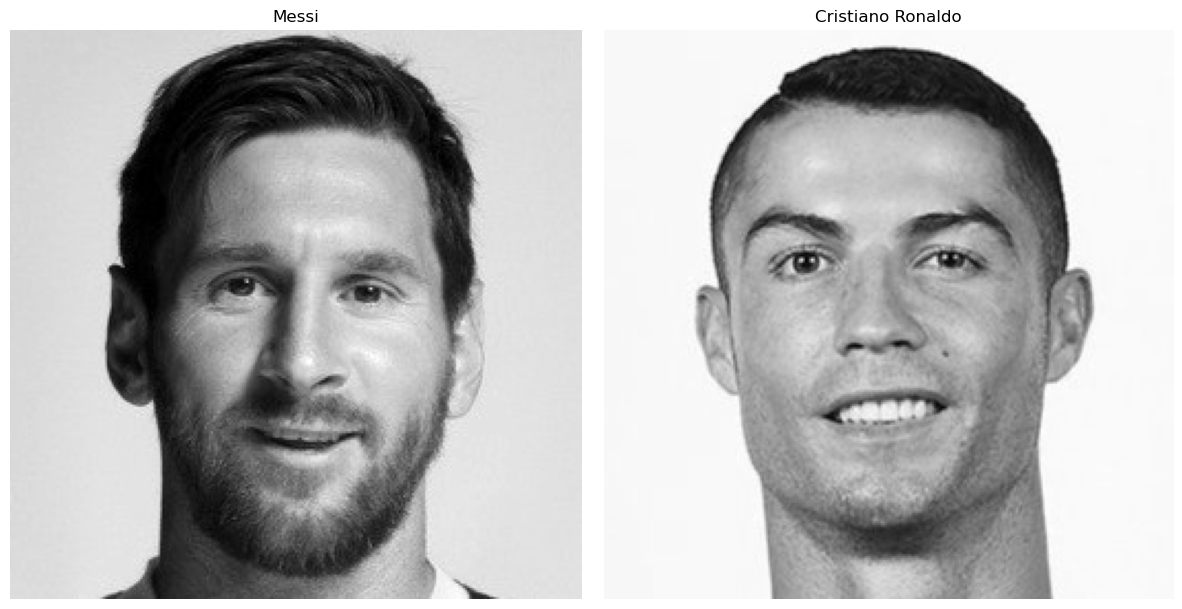

In [10]:
# Load images
messi = io.imread('./images_notebook/messi.jpg')
cr = io.imread('./images_notebook/cr.jpg')

# Convert to grayscale
messi_gray = rgb2gray(messi)
cr_gray = rgb2gray(cr)

# Plot both images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(messi_gray, cmap='gray')
axes[0].set_title('Messi')
axes[0].axis('off')

axes[1].imshow(cr_gray, cmap='gray')
axes[1].set_title('Cristiano Ronaldo')
axes[1].axis('off')

plt.tight_layout()
plt.show()

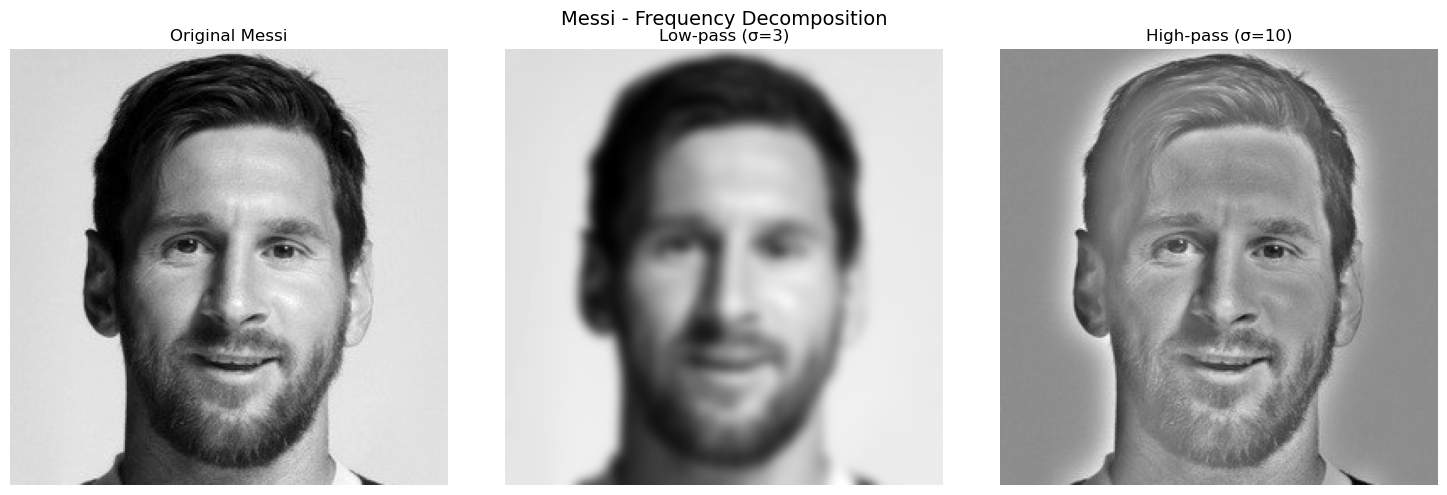

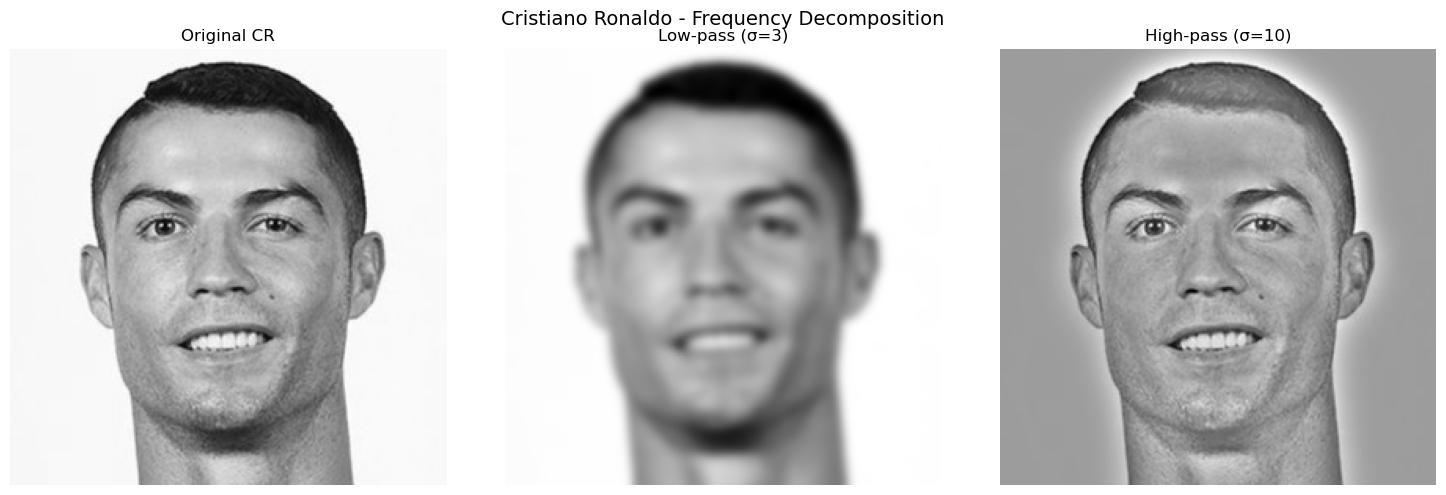

In [14]:
# Apply low-pass filter (lower sigma for less blurring)
messi_low = gaussian(messi_gray, sigma=3)
cr_low = gaussian(cr_gray, sigma=3)

# Apply high-pass filter (higher sigma for more detail extraction)
messi_high = messi_gray - gaussian(messi_gray, sigma=10)
cr_high = cr_gray - gaussian(cr_gray, sigma=10)

# Normalize high-pass to [0, 1] for visualization
messi_high_norm = (messi_high - messi_high.min()) / (messi_high.max() - messi_high.min())
cr_high_norm = (cr_high - cr_high.min()) / (cr_high.max() - cr_high.min())

# Visualize Messi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(messi_gray, cmap='gray')
axes[0].set_title('Original Messi')
axes[0].axis('off')

axes[1].imshow(messi_low, cmap='gray')
axes[1].set_title('Low-pass (σ=3)')
axes[1].axis('off')

axes[2].imshow(messi_high_norm, cmap='gray')
axes[2].set_title('High-pass (σ=10)')
axes[2].axis('off')

plt.suptitle('Messi - Frequency Decomposition', fontsize=14)
plt.tight_layout()
plt.show()

# Visualize CR
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cr_gray, cmap='gray')
axes[0].set_title('Original CR')
axes[0].axis('off')

axes[1].imshow(cr_low, cmap='gray')
axes[1].set_title('Low-pass (σ=3)')
axes[1].axis('off')

axes[2].imshow(cr_high_norm, cmap='gray')
axes[2].set_title('High-pass (σ=10)')
axes[2].axis('off')

plt.suptitle('Cristiano Ronaldo - Frequency Decomposition', fontsize=14)
plt.tight_layout()
plt.show()

b) Create hybrid images and visualize them. A hybrid image is obtained by combining the low and high frequencies of the image, i.e. combining the results obtained by the `low-pass` and `high-pass` filters.

<img src="images_notebook/Fusion.gif" width="400" height="400">

Hybrid (I1, I2) = L(I1) + H(I2)

1. Analyze which is the best way of showing it if our aim is to see Messi's face. 
2. Additionally, rescale the image to a different size and comment the results. 

Present the different visualizations of the experiment performed.

<img src="images_notebook/Hybrid.png">


In [19]:
# Create hybrid images
# Hybrid 1: Low frequencies from Messi + High frequencies from CR
hybrid1 = messi_low + cr_high

# Hybrid 2: Low frequencies from CR + High frequencies from Messi
hybrid2 = cr_low + messi_high

# Normalize for display
hybrid1_norm = np.clip(hybrid1, 0, 1)
hybrid2_norm = np.clip(hybrid2, 0, 1)

# Visualize hybrids
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(hybrid1_norm, cmap='gray')
axes[0].set_title('Hybrid: L(Messi) + H(CR)')
axes[0].axis('off')

axes[1].imshow(hybrid2_norm, cmap='gray')
axes[1].set_title('Hybrid: L(CR) + H(Messi)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# To see Messi's face better, use Hybrid 1 (L(Messi) + H(CR))
print("To see Messi's face: Use Hybrid 1 - L(Messi) + H(CR)")
print("Low frequencies (Messi) dominate at normal viewing distance")
print("High frequencies (CR details) become visible when zoomed in")

# Rescale to different sizes
scales = [0.25, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(1, len(scales), figsize=(16, 4))

for idx, scale in enumerate(scales):
    hybrid_scaled = rescale(hybrid1_norm, scale, anti_aliasing=True)
    axes[idx].imshow(hybrid_scaled, cmap='gray')
    axes[idx].set_title(f'Scale: {scale}x')
    axes[idx].axis('off')

plt.suptitle('Hybrid Image at Different Scales', fontsize=14)
plt.tight_layout()
plt.show()

print("\nObservations at different scales:")
print("- Small scale (far away): Low frequencies dominate → See Messi more clearly")
print("- Large scale (close up): High frequencies become visible → See more CR details")
print("- This is the essence of hybrid images: different content at different viewing distances")

ValueError: operands could not be broadcast together with shapes (258,259) (278,278) 

### 2.7 Anonimization of sensitive information

One of the important problems in Computer Vision as a science that manages data (images and videos) is the anonimization of sensitive information appearing in the images.
For example, it is common in applications like Google Street View, where the faces and license plates are anonymized.
The file `./images_notebook/car.png` contains two cars. Anonimize the license plates of the cars using the techniques learned in this practicum.

Modify only the license plates of the cars, keeping the rest of the image unchanged.

![car](images_notebook/car.png)

Car image shape: (473, 806, 3)


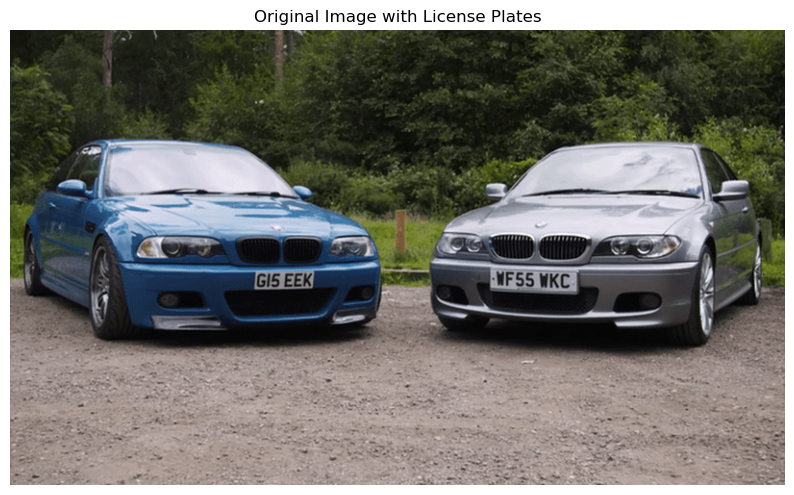


To anonymize license plates, we can:
1. Apply strong Gaussian blur to the license plate regions
2. Use pixelation (downscale and upscale)
3. Replace with a solid color block


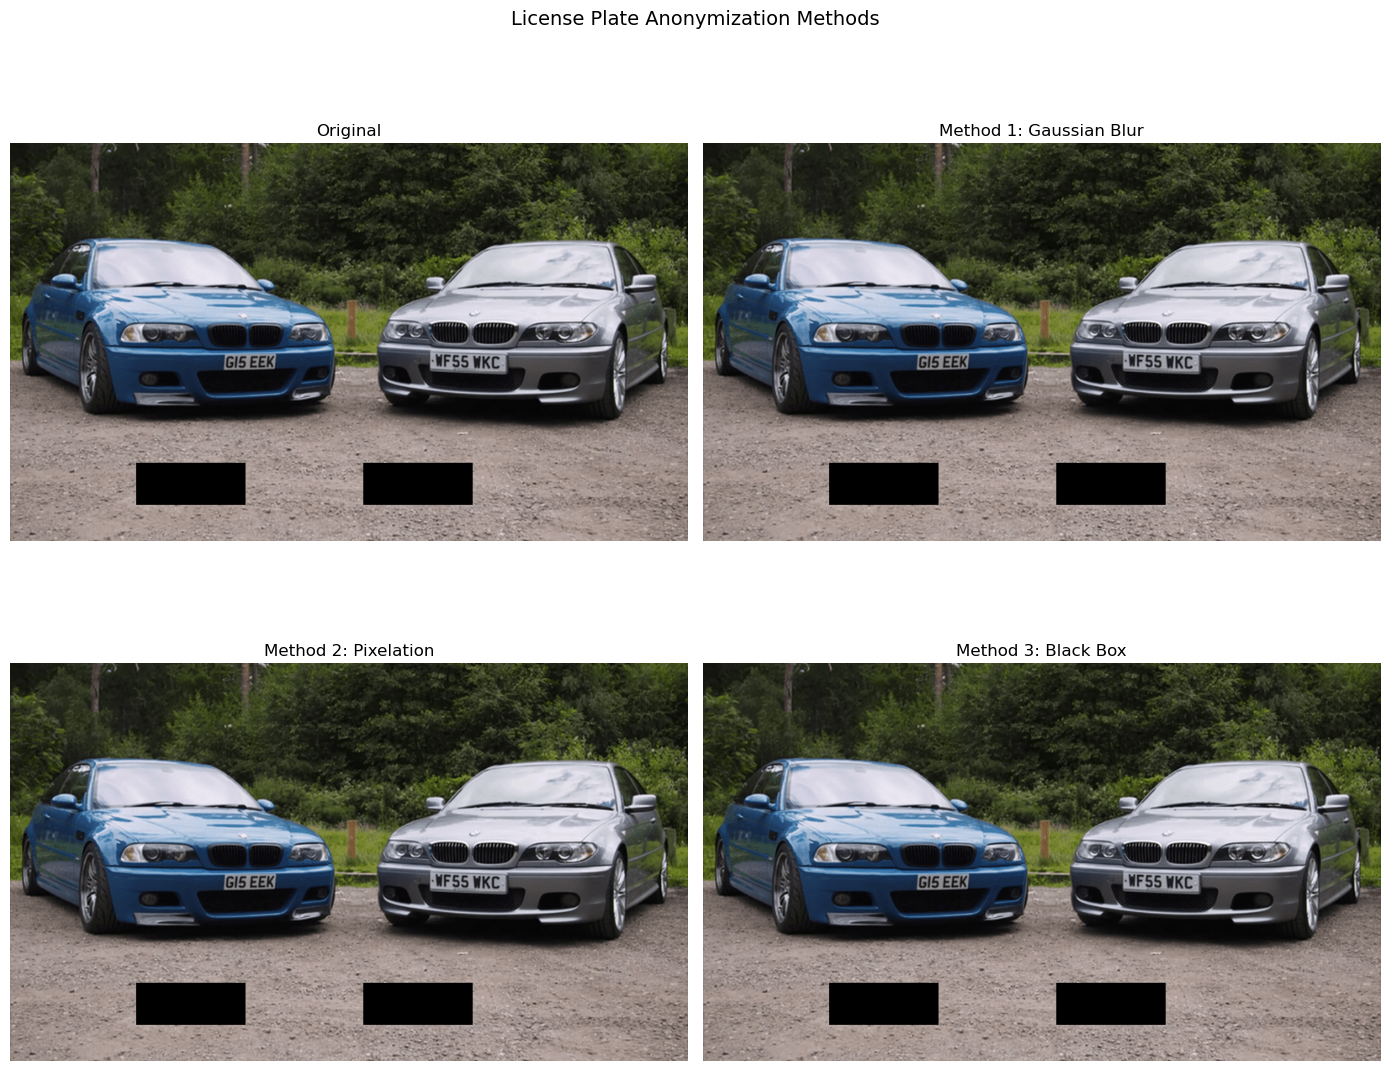


Note: The coordinates for license plate regions are approximate.
Adjust the 'license_plate_regions' list with the correct coordinates from the actual image.
You can use plt.ginput() or manual inspection to find the exact coordinates.


In [18]:
# Load the car image
car = io.imread('./images_notebook/car.png')
car_copy = car.copy()

print(f"Car image shape: {car.shape}")

# Display original image
plt.figure(figsize=(10, 6))
plt.imshow(car)
plt.title('Original Image with License Plates')
plt.axis('off')
plt.show()

# Manually define regions of license plates (you need to adjust these coordinates)
# These are example coordinates - adjust based on actual image
# Format: (row_start, row_end, col_start, col_end)

# For demonstration, let's identify approximate regions
# You should adjust these coordinates based on the actual image

print("\nTo anonymize license plates, we can:")
print("1. Apply strong Gaussian blur to the license plate regions")
print("2. Use pixelation (downscale and upscale)")
print("3. Replace with a solid color block")

# Method 1: Gaussian blur on specific regions
# Example regions (adjust these based on actual license plate locations):
license_plate_regions = [
    (380, 430, 150, 280),  # First car - adjust coordinates
    (380, 430, 420, 550),  # Second car - adjust coordinates
]

car_blurred = car.copy()
for (r1, r2, c1, c2) in license_plate_regions:
    # Extract region
    plate_region = car[r1:r2, c1:c2]
    # Apply strong blur
    if len(plate_region.shape) == 3:
        for channel in range(3):
            plate_region[:, :, channel] = gaussian(plate_region[:, :, channel], sigma=15)
    else:
        plate_region = gaussian(plate_region, sigma=15)
    # Put back
    car_blurred[r1:r2, c1:c2] = plate_region

# Method 2: Pixelation
car_pixelated = car.copy()
for (r1, r2, c1, c2) in license_plate_regions:
    plate_region = car[r1:r2, c1:c2]
    # Downscale and upscale to create pixelation effect
    small = rescale(plate_region, 0.1, anti_aliasing=False, channel_axis=2 if len(plate_region.shape)==3 else None)
    pixelated = resize(small, (r2-r1, c2-c1), anti_aliasing=False)
    car_pixelated[r1:r2, c1:c2] = (pixelated * 255).astype(np.uint8)

# Method 3: Black box
car_blackbox = car.copy()
for (r1, r2, c1, c2) in license_plate_regions:
    car_blackbox[r1:r2, c1:c2] = 0  # Black box

# Visualize all methods
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0, 0].imshow(car)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(car_blurred)
axes[0, 1].set_title('Method 1: Gaussian Blur')
axes[0, 1].axis('off')

axes[1, 0].imshow(car_pixelated)
axes[1, 0].set_title('Method 2: Pixelation')
axes[1, 0].axis('off')

axes[1, 1].imshow(car_blackbox)
axes[1, 1].set_title('Method 3: Black Box')
axes[1, 1].axis('off')

plt.suptitle('License Plate Anonymization Methods', fontsize=14)
plt.tight_layout()
plt.show()

print("\nNote: The coordinates for license plate regions are approximate.")
print("Adjust the 'license_plate_regions' list with the correct coordinates from the actual image.")
print("You can use plt.ginput() or manual inspection to find the exact coordinates.")